<a href="https://colab.research.google.com/github/BT744/Global-Coffee-Analysis/blob/main/assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 4 by Becky Tsang

We will be using the Iris database imported from the seaborn library. It consists of 5 columns and 150 rows. The target variable is 'species'.

The goal is the classify flowers according to their features (independent variables).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# install iris dataset from seaborn library
iris = sns.load_dataset('iris')

In [ ]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
#Possible species
iris['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

We need to clean and prepare our data by converting species into numerical values.

In [ ]:
iris.replace('setosa', 0, inplace=True)#the changes will be applied directly to the original DataFrame without returning a new DataFrame.
iris.replace('versicolor', 1, inplace=True)
iris.replace('virginica', 2, inplace=True)

iris.dropna(axis=0, inplace=True) #remove Nan values

/tmp/ipython-input-1129711623.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iris.replace('virginica', 2, inplace=True)


In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


Doing a pairplot on our data, we are going to colour code our points based on the species of our iris.

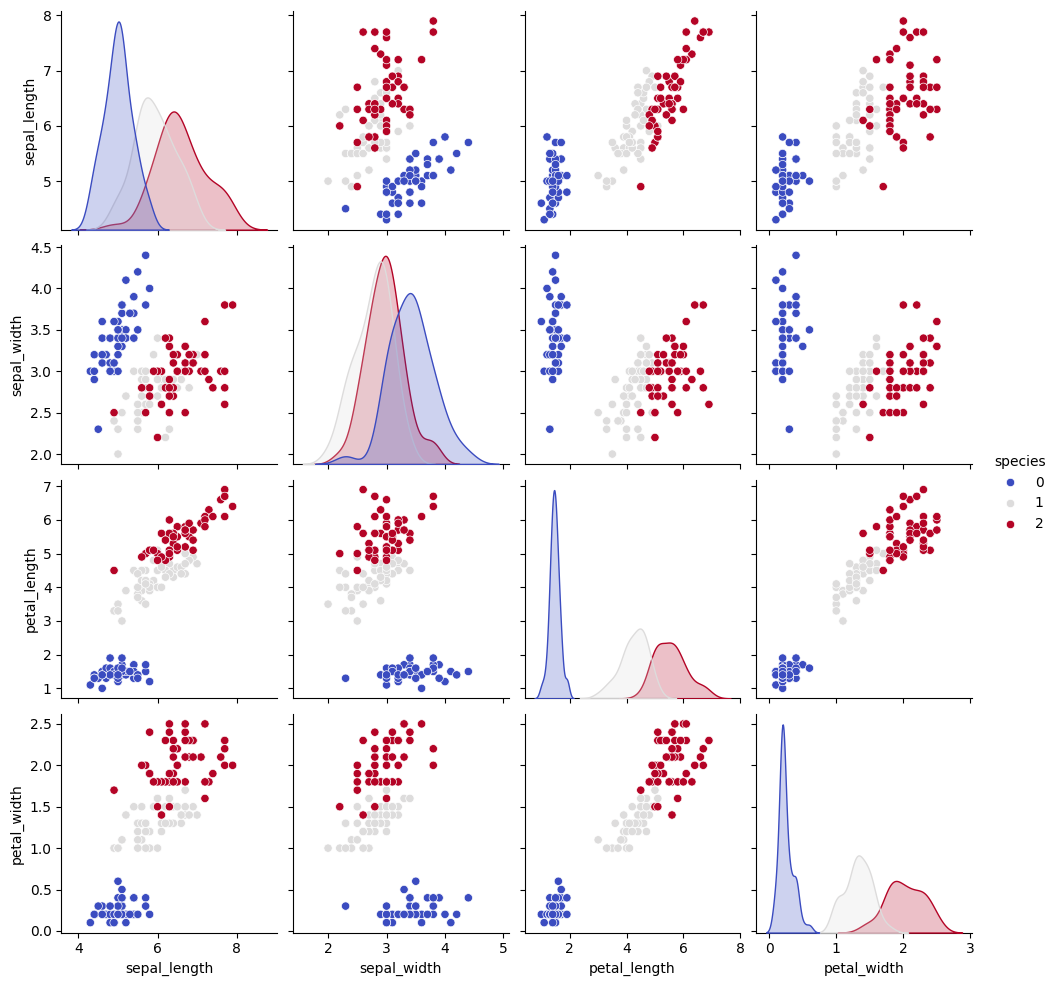

In [ ]:
sns.pairplot(iris,hue='species',palette='coolwarm')

K-Nearest Neighbors (Supervised)

We will need to split data and train algorithm

In [ ]:
#Remove the dependent data (our y) from our independent data (our x values)
X, y = iris.drop('species', axis=1), iris['species'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=87)

We are going to use KNN to train our algorithm, and we are going to start with K=3

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

Scoring our result we get

In [ ]:
knn.score(X_test, y_test)

0.9777777777777777

In [ ]:
predictions = knn.predict(X_test)

Checking classification report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      0.93      0.97        15
           2       0.93      1.00      0.97        14

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



Our model is proven to be very accurate with 98% overall accuracy based on the classification report and accuracy score 97.777%. For setosa, all predictions are correct with no errors hence 1.00 for precision and recall.

For versicolor, the prediction is 1.0 which means all predicted flowers were correct however with 93% recall, 7% of the verisolors were predicted to be other types of flowers in error (false negative).

For virginica, 93% of the flowers were true positives and 7% resulted in false positives (not this species). Recall rate is 1.00 which means no virginica was misclassified.

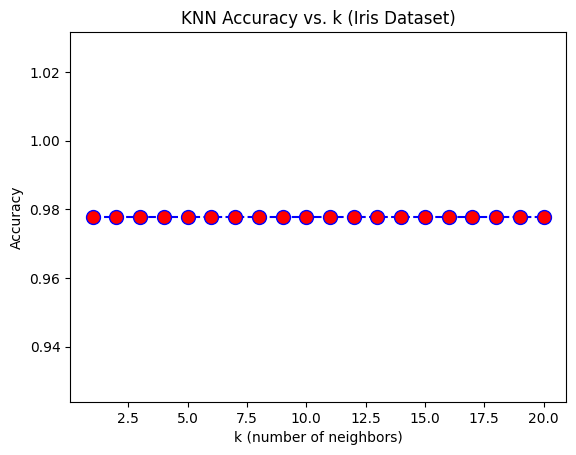

In [ ]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    accuracies.append(acc)

# Plot KNN Accuracy vs. k for iris dataset based on k ranging from 1 to 21.
plt.plot(k_values, accuracies,color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs. k (Iris Dataset)")
plt.show()

We ran our knn classifier on values of k from 1 to 21. The accuracy score remains consistent at 0.977 despite k changing.

In [ ]:
#Create confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, predictions)
print(cm)

[[16  0  0]
 [ 0 14  1]
 [ 0  0 14]]


In [ ]:
iris = sns.load_dataset('iris')
labels = iris.species

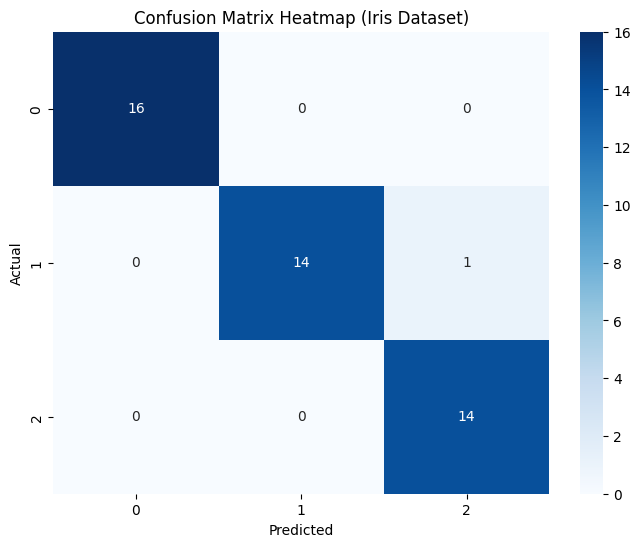

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap (Iris Dataset)')
plt.show()

Based on the confusion matrix heatmap, the model performed very well. Setosa was predicted to be 16 times accurate. Versicolor had 14 correct and 1 was incorrectly classified as Virginica. Virginica had 14 accurately predicted. Overall the test sample showed exceptional performance since 1 out of 45 flowers were misclassified.

K-Means Clustering (Unsupervised)

#Since the original dataframe was changed, we will need to convert the categorical values to numerical values again.

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
iris.replace('setosa', 0, inplace=True)#the changes will be applied directly to the original DataFrame without returning a new DataFrame.
iris.replace('versicolor', 1, inplace=True)
iris.replace('virginica', 2, inplace=True)

iris.dropna(axis=0, inplace=True) #remove Nan values

Divide our clusters into 3 groups (k=3)

In [ ]:
kmeans = KMeans(n_clusters=3)

In [ ]:
kmeans.fit(iris.drop('species',axis=1))#The code fits a K-means clustering model to the iris dataset using all features except for the species column.
#The species column is removed from the iris DataFrame because it is the target variable, and clustering is an unsupervised learning method that doesn’t use target labels.

KMeans(n_clusters=3)

In [ ]:
kmeans.cluster_centers_

array([[5.006     , 3.428     , 1.462     , 0.246     ],
       [5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(iris['species'],kmeans.labels_))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.77      0.96      0.86        50
           2       0.95      0.72      0.82        50

    accuracy                           0.89       150
   macro avg       0.91      0.89      0.89       150
weighted avg       0.91      0.89      0.89       150



The average feature values for each cluster is represented by the cluster centers(centroids). The overall accuracy rate is 89%. Setosa is predicted 100% accurately. Versicolor has a precision of 0.77 which means 23% were false positives and misclassified as virginica. The recall is 96%, 4% were misclassified.

Virginica has 95% accurate predictions while 5% were incorrect. For recall, 72% of the virinica was classified correctly and the remaining 28% was misclassified.

Divide our clusters to 7 groups (k=7)

In [ ]:
kmeans = KMeans(n_clusters=7)
kmeans.fit(iris.drop('species',axis=1))

KMeans(n_clusters=7)

In [ ]:
kmeans.cluster_centers_

array([[5.24285714, 3.66785714, 1.5       , 0.28214286],
       [6.24857143, 2.84571429, 4.78857143, 1.58285714],
       [7.475     , 3.125     , 6.3       , 2.05      ],
       [5.69444444, 2.76111111, 4.20555556, 1.3       ],
       [6.52916667, 3.05833333, 5.50833333, 2.1625    ],
       [4.70454545, 3.12272727, 1.41363636, 0.2       ],
       [5.32727273, 2.45454545, 3.59090909, 1.11818182]])

When K is 3, it categorizes the flowers into three clusters, one for each specie. If K is 7, then the flowers are further located into subgroups of each species.